In [40]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [41]:
df=df.dropna(subset='salary_year_avg')

In [42]:
df_ds=df[df['job_title_short']=='Data Scientist']

In [43]:
df_exploded=df_ds.explode('job_skills')

In [44]:
df_groups=df_exploded.groupby('job_skills')['salary_year_avg'].agg(['median','size']).sort_values('size',ascending=False)

In [45]:
df_groups

,median,size
job_skills,,
python,130500.0,4309
sql,132500.0,3146
r,125000.0,2484
tableau,125000.0,1279
sas,119000.0,1226
...,...,...
monday.com,79019.0,1
redhat,189500.0,1
qt,110000.0,1


In [46]:
total_jobs=df_ds['job_title_short'].size

In [47]:
df_groups['perccent']=df_groups['size'].div(total_jobs/100,axis=0)

In [48]:
df_groups_filtered=df_groups[df_groups['perccent']>8]

<Axes: xlabel='perccent', ylabel='median'>

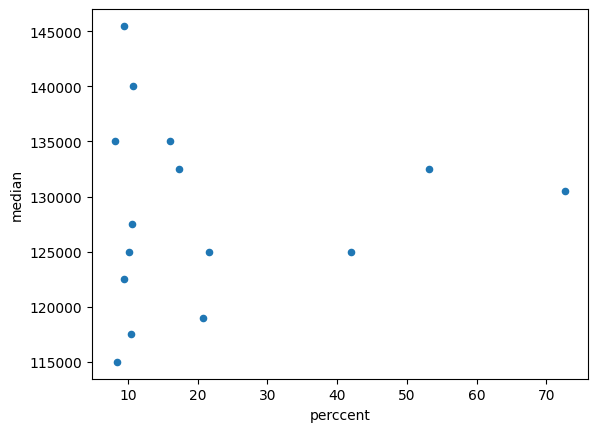

In [49]:
df_groups_filtered.plot(kind='scatter',x='perccent',y='median')

In [60]:
new_dict={}
df=df.dropna(subset='job_type_skills')
for i in df['job_type_skills']: 
    val=ast.literal_eval(i)
    for key,val in val.items(): 
        if key not in new_dict: 
            new_dict[key]=val 
        else: 
            new_dict[key]=new_dict[key]+val 

        

In [62]:
for key,val in new_dict.items(): 
    new_dict[key]=list(set(val))

In [66]:
df_new=pd.DataFrame(new_dict.items(),columns=['skill_type','skills'])

In [74]:
df_new=df_new.explode('skills')
df_new

,skill_type,skills
0,analyst_tools,tableau
0,analyst_tools,powerpoint
0,analyst_tools,sharepoint
0,analyst_tools,qlik
0,analyst_tools,sas
...,...,...
9,sync,symphony
9,sync,unify
9,sync,webex
9,sync,zoom


In [76]:
df_merge=df_groups_filtered.merge(df_new,left_on='job_skills',right_on='skills')

In [77]:
df_merge

,median,size,perccent,skill_type,skills
0,130500.0,4309,72.762580,programming,python
1,132500.0,3146,53.123945,programming,sql
2,125000.0,2484,41.945289,programming,r
3,125000.0,1279,21.597433,analyst_tools,tableau
4,119000.0,1226,20.702465,analyst_tools,sas
5,119000.0,1226,20.702465,programming,sas
6,132500.0,1021,17.240797,cloud,aws
7,135000.0,944,15.940561,libraries,spark
8,140000.0,637,10.756501,libraries,tensorflow
9,127500.0,627,10.587639,cloud,azure


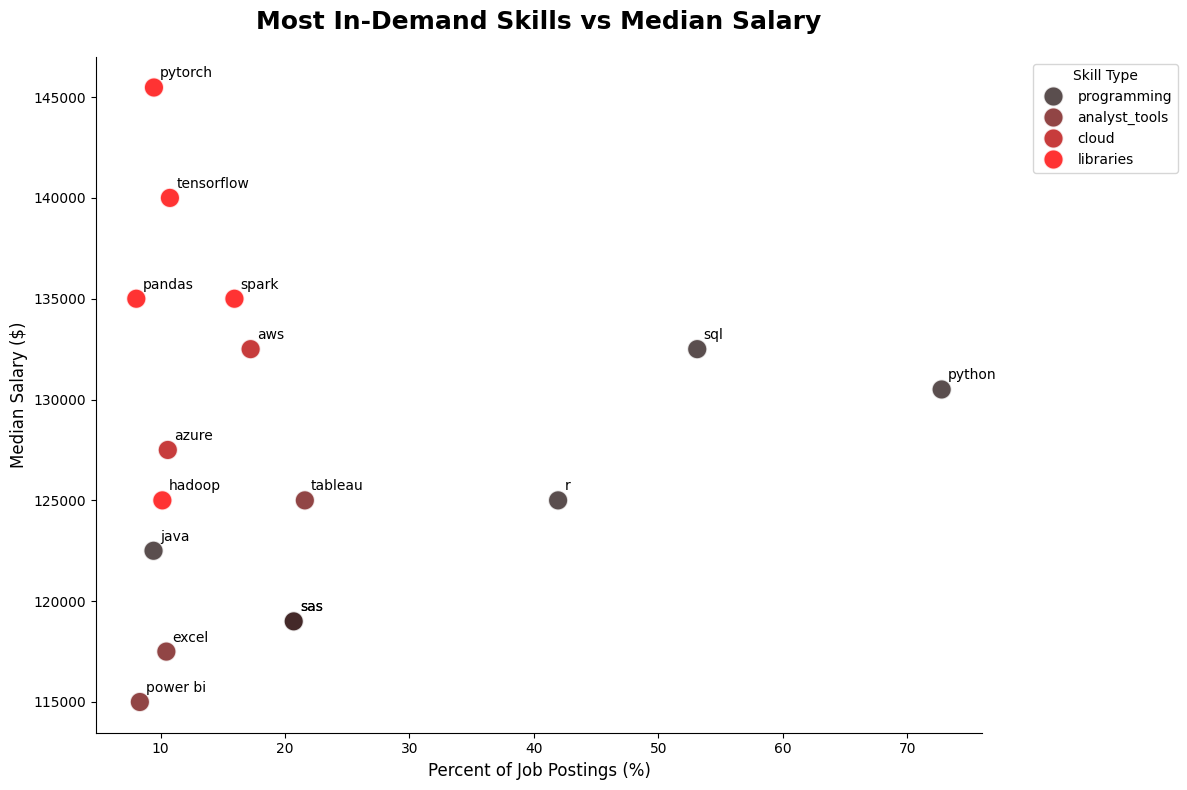

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_merge,
    x='perccent',
    y='median',
    hue='skill_type',
    s=200,
    alpha=0.8,
    palette='dark:r'
)

# Add skill labels
for _, row in df_merge.iterrows():
    ax.text(
        row['perccent'] + 0.5,
        row['median'] + 500,
        row['skills'],
        fontsize=10
    )

# Formatting
ax.set_title(
    'Most In-Demand Skills vs Median Salary',
    fontsize=18,
    weight='bold',
    pad=20
)

ax.set_xlabel('Percent of Job Postings (%)', fontsize=12)
ax.set_ylabel('Median Salary ($)', fontsize=12)

# Format y-axis
ax.ticklabel_format(style='plain', axis='y')

# Move legend
plt.legend(
    title='Skill Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

sns.despine()
plt.tight_layout()

plt.show()